In [1]:
import warnings
warnings.filterwarnings("ignore", message=".*pandas only supports SQLAlchemy.*")
import pymysql
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# 设置绘图风格
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="white", font='SimHei')

def get_db_connection():
    """建立 StarRocks 数据库连接"""
    return pymysql.connect(
        host='192.168.144.101',
        port=9030,
        user='hadoop',
        password='hadoop',
        charset='utf8'
    )

def fetch_data():
    """从 StarRocks 获取各城市房源汇总数据"""
    conn = get_db_connection()
    # SQL 路径：catalog.db.table
    query = """
    SELECT 
        city, 
        SUM(total_house_count) as total_count
    FROM iceberg_catalog.ershoufang.ads_city_overview_daily
    GROUP BY city
    ORDER BY total_count DESC
    """
    try:
        df = pd.read_sql(query, conn)
        return df
    finally:
        conn.close()

In [2]:
def plot_pareto_house_count():
    """绘制帕累托图：柱状图表示数量，折线图表示累计百分比"""
    df = fetch_data()
    
    if df is None or df.empty:
        return

    # 计算累计频率 (Cumulative Percentage)
    df['cum_percentage'] = 100 * df['total_count'].cumsum() / df['total_count'].sum()

    # --- 开始绘图 ---
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # 1. 绘制左侧轴：柱状图 (Bar)
    color_bar = 'steelblue'
    sns.barplot(x='city', y='total_count', data=df, ax=ax1, color=color_bar, alpha=0.8)
    ax1.set_xlabel('城市', fontsize=12)
    ax1.set_ylabel('房源总数 (套)', fontsize=12, color=color_bar)
    ax1.tick_params(axis='y', labelcolor=color_bar)
    plt.xticks(rotation=45)

    # 2. 绘制右侧轴：累计百分比曲线 (Line)
    ax2 = ax1.twinx() 
    color_line = 'crimson'
    ax2.plot(df['city'], df['cum_percentage'], color=color_line, marker='D', ms=7, linewidth=2, label='累计百分比')
    
    # 设置右轴范围和格式
    ax2.set_ylim(0, 110)
    ax2.set_ylabel('累计百分比 (%)', fontsize=12, color=color_line)
    ax2.tick_params(axis='y', labelcolor=color_line)

    # 3. 添加 80% 辅助线 (帕累托法则核心线)
    ax2.axhline(80, color='orange', linestyle='--', alpha=0.6)
    ax2.text(len(df)-1, 82, '80% 阈值', color='orange', fontweight='bold', ha='right')

    # 4. 图表细节美化
    plt.title('全国房源分布帕累托图', fontsize=16, pad=20)
    
    # 为柱状图添加数值标签
    for i, count in enumerate(df['total_count']):
        ax1.text(i, count + (df['total_count'].max() * 0.01), f'{int(count)}', ha='center', fontsize=10)

    plt.tight_layout()
    plt.show()

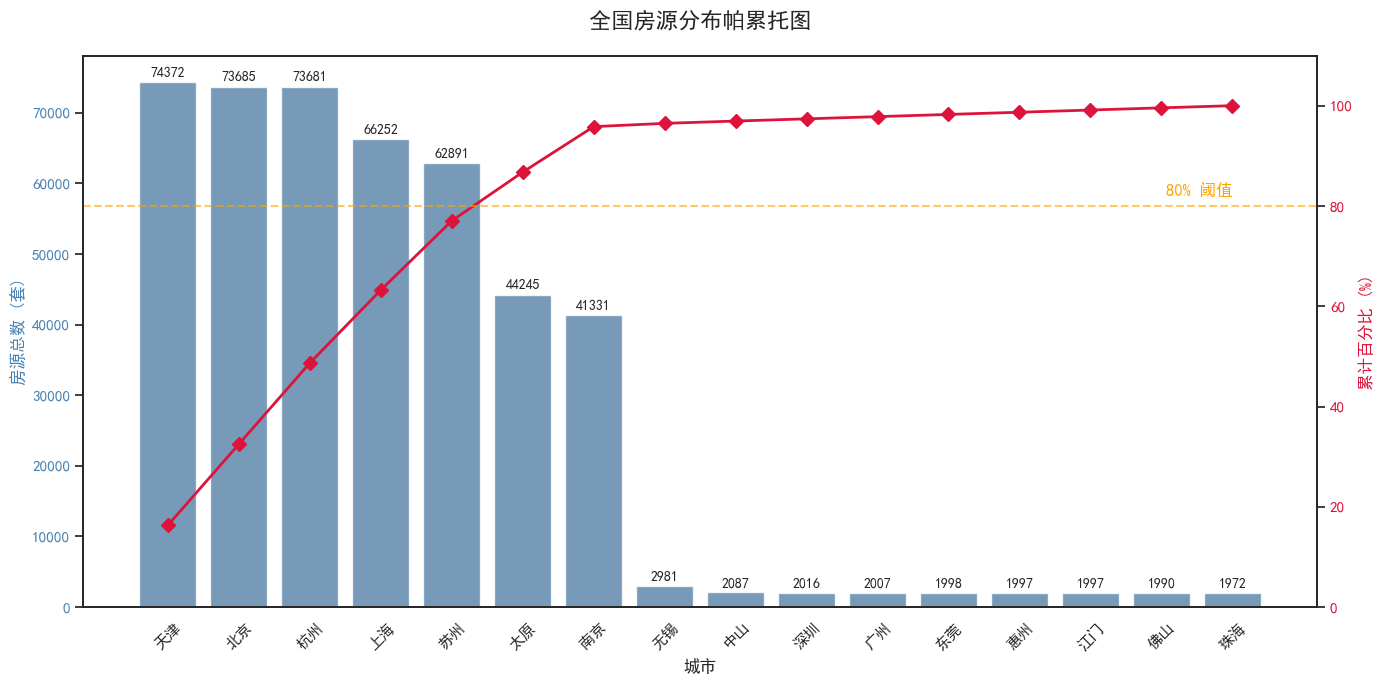

In [3]:
if __name__ == "__main__":
    plot_pareto_house_count()